In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install tensorflow keras opencv-python scikit-image imutils 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def order_points(pts):
    # Order: top-left, top-right, bottom-right, bottom-left
    rect = np.zeros((4, 2), dtype='float32')
    
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left

    return rect

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Compute width
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))

    # Compute height
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # Destination points
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype='float32')

    # Perspective transform
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped


In [3]:
def deskew(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Invert colors
    gray = cv2.bitwise_not(gray)

    # Threshold
    thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY | cv2.THRESH_OTSU
    )[1]

    # Find coordinates of all non-zero pixels
    coords = np.column_stack(np.where(thresh > 0))

    # Compute rotated bounding box
    angle = cv2.minAreaRect(coords)[-1]

    # Adjust angle
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # Rotate image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated, angle


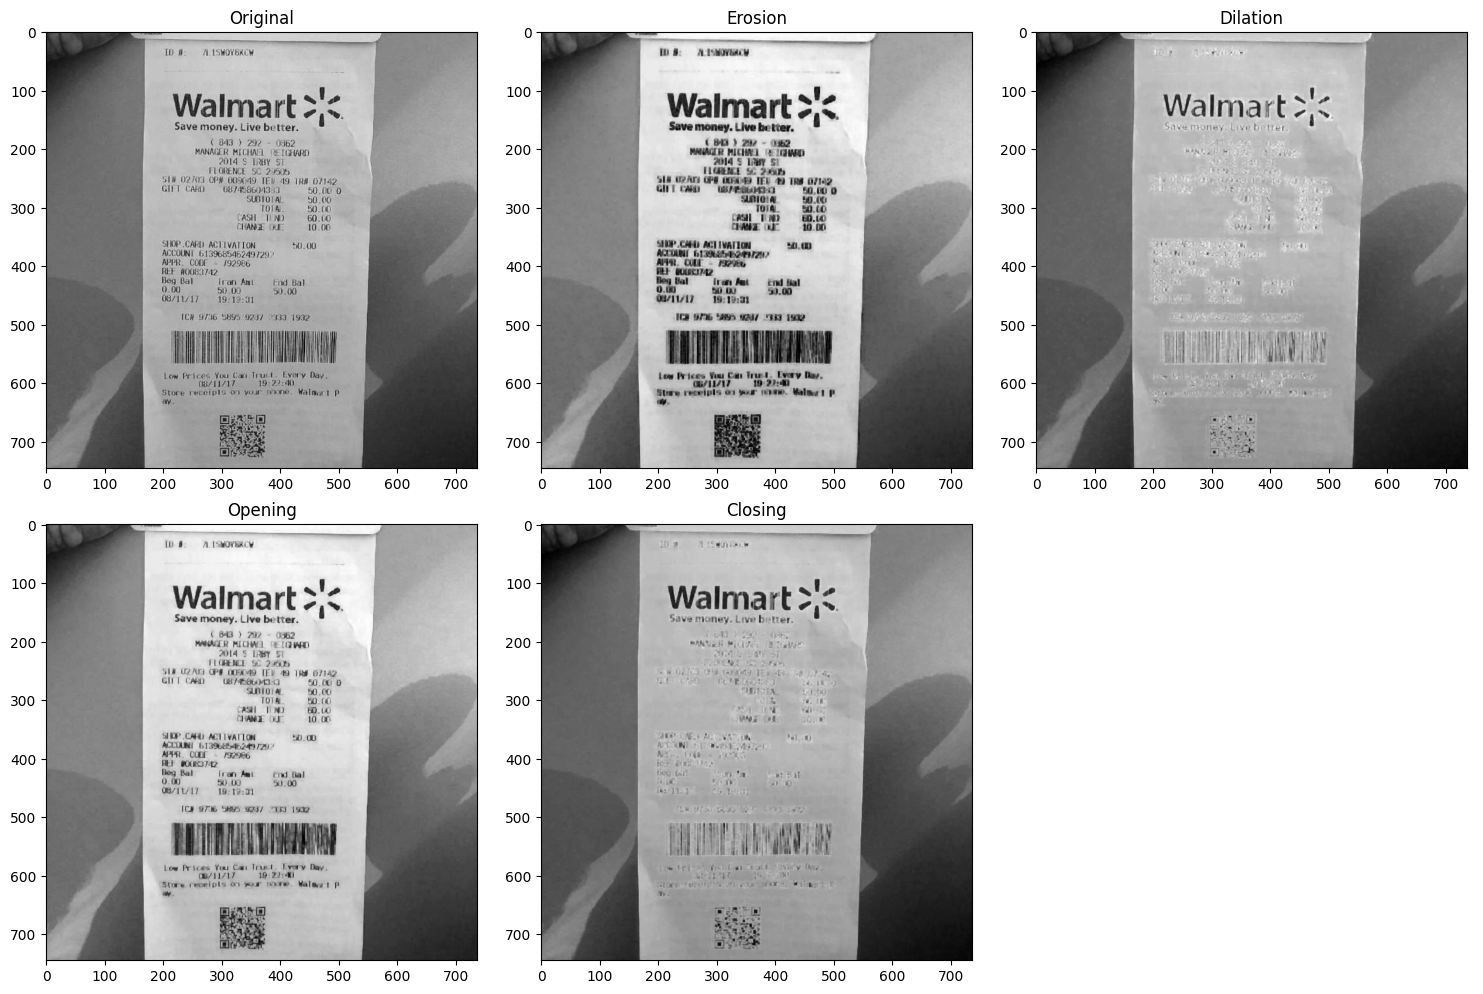

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/kaggle/input/datasets/sheikhhaseeb123/ocrdatasetimages/images/13.jpg')

# Check if image loaded
if img is None:
    raise ValueError("Image not found. Check file path.")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define kernel
kernel = np.ones((3, 3), np.uint8)

# Erosion - remove noise
erosion = cv2.erode(gray, kernel, iterations=1)

# Dilation - fill gaps
dilation = cv2.dilate(gray, kernel, iterations=1)

# Opening - remove small noise
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

# Closing - fill small holes
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

# Display all results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('Opening')

axes[1, 1].imshow(closing, cmap='gray')
axes[1, 1].set_title('Closing')

# Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
